# Harsh Driving Event Detection Project

This notebook trains and deploys models to detect:
- sudden_acceleration
- sudden_braking
- harsh_left_turn
- harsh_right_turn
- harsh_left_lane_change
- harsh_right_lane_change

Input stream schema expected from CARLA/manual drive:
`sr_no, timestamp, road_type, harsh_event, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, mag_x, mag_y, mag_z, event_class`

## 1. Environment Setup and Reproducibility

In [35]:
# If needed, uncomment and run once.
%pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn torch joblib

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sys

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd().resolve().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
DATASET_DIR = ROOT / 'dataset'
ARTIFACT_DIR = ROOT / 'artifacts'
SRC_DIR = ROOT / 'src'
ARTIFACT_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

sns.set_style('whitegrid')
print(f'ROOT={ROOT}')
print(f'DATASET_DIR exists: {DATASET_DIR.exists()}')
print(f'ARTIFACT_DIR={ARTIFACT_DIR}')

Note: you may need to restart the kernel to use updated packages.
ROOT=/home/pw26_rr_09/pw26_rr_07/baseModel
DATASET_DIR exists: True
ARTIFACT_DIR=/home/pw26_rr_09/pw26_rr_07/baseModel/artifacts


## 2. Dataset Discovery and File-Level Metadata Parsing

In [36]:
def parse_speed(file_name: str):
    lowered = file_name.lower()
    if '20kmph' in lowered:
        return 20
    if '40kmph' in lowered:
        return 40
    if '60kmph' in lowered:
        return 60
    return 0

csv_files = sorted(DATASET_DIR.glob('*.csv'))
file_index = pd.DataFrame({
    'file_name': [f.name for f in csv_files],
    'road_type_from_name': [f.name.split('_')[0] for f in csv_files],
    'speed_kmph': [parse_speed(f.name) for f in csv_files],
})
file_index['file_id'] = np.arange(len(file_index))
file_index.head(10)

,file_name,road_type_from_name,speed_kmph,file_id
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,paved,60,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,paved,0,1
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,paved,0,2
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,paved,20,3
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,paved,40,4
5,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,5
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,6
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,7
8,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,8
9,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,paved,20,9


## 3. CSV Ingestion and Schema Validation

In [37]:
EXPECTED_COLUMNS = [
    'sr_no', 'timestamp', 'road_type', 'harsh_event',
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'mag_x', 'mag_y', 'mag_z',
    'event_class',
]

imu_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']

def robust_timestamp_parse(series: pd.Series) -> pd.Series:
    # Handles both formats: 22-3-2023_20:14:29:15484 and 22-3-2023 20:14:29:15484
    s = series.astype(str).str.replace('_', ' ', regex=False)
    return pd.to_datetime(s, format='%d-%m-%Y %H:%M:%S:%f', errors='coerce')

frames = []
schema_issues = []
for fp in csv_files:
    df = pd.read_csv(fp)
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        schema_issues.append((fp.name, missing))
        continue

    for c in imu_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['event_class'] = pd.to_numeric(df['event_class'], errors='coerce').fillna(0).astype(int)
    df['timestamp_parsed'] = robust_timestamp_parse(df['timestamp'])
    df = df.sort_values('timestamp_parsed', kind='mergesort').reset_index(drop=True)

    missing_ratio = df[imu_cols].isna().mean().mean()
    df = df.dropna(subset=imu_cols).copy()

    df['source_file'] = fp.name
    frames.append(df)

print('Schema issues:', schema_issues if schema_issues else 'None')
raw_df = pd.concat(frames, ignore_index=True)
print('Rows:', len(raw_df), 'Files:', raw_df['source_file'].nunique())
print('Global missing ratio over IMU before drop:', round(missing_ratio, 5))
raw_df.head()

Schema issues: None
Rows: 32987 Files: 54
Global missing ratio over IMU before drop: 0.0


,sr_no,timestamp,road_type,harsh_event,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,event_class,timestamp_parsed,source_file
0,1,22-3-2023 20:32:39:320352,paved,sudden-acc,-3.353295,-4.104586,2.833607,0.037641,-0.069241,0.131234,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.320352,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
1,2,22-3-2023 20:32:39:685071,paved,sudden-acc,-2.165347,-2.073578,-0.260807,-0.017754,-0.196808,0.142686,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.685071,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
2,3,22-3-2023 20:32:39:697380,paved,sudden-acc,-2.510235,-1.661629,14.320298,0.070931,0.002666,0.153073,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.697380,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
3,4,22-3-2023 20:32:39:705378,paved,sudden-acc,-1.303127,3.090163,5.219082,0.060544,0.144881,0.147213,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.705378,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
4,5,22-3-2023 20:32:39:737391,paved,sudden-acc,6.140707,-2.351405,-1.496656,-0.005237,-0.019972,0.128571,-84.325073,-81.466423,82.771537,0,2023-03-22 20:32:39.737391,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...


## 4. Label Strategy for Multi-Class Harsh Event Detection

In [38]:
from harsh_event_model import normalize_event_name, load_row_labeled_data

row_labeled_df = load_row_labeled_data(DATASET_DIR)
print('Row-level labels:')
print(row_labeled_df['event_label'].value_counts())

class_to_id = {
    'safe': 0,
    'sudden_acceleration': 1,
    'sudden_braking': 2,
    'harsh_left_turn': 3,
    'harsh_right_turn': 4,
    'harsh_left_lane_change': 5,
    'harsh_right_lane_change': 6,
}
id_to_class = {v: k for k, v in class_to_id.items()}
row_labeled_df['class_id'] = row_labeled_df['event_label'].map(class_to_id).fillna(0).astype(int)
row_labeled_df[['source_file', 'harsh_event', 'event_class', 'event_label', 'class_id']].head()

Row-level labels:
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: event_label, dtype: int64


,source_file,harsh_event,event_class,event_label,class_id
0,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
2,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
3,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
4,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0


## 5. Signal Cleaning and Sensor Feature Engineering

In [39]:
clean_df = row_labeled_df.copy()

# Light denoising: rolling median over a short window.
for col in imu_cols:
    clean_df[col] = (
        clean_df.groupby('source_file')[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

clean_df['acc_mag'] = np.sqrt(clean_df['acc_x']**2 + clean_df['acc_y']**2 + clean_df['acc_z']**2)
clean_df['gyro_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2 + clean_df['gyro_z']**2)
clean_df['mag_mag'] = np.sqrt(clean_df['mag_x']**2 + clean_df['mag_y']**2 + clean_df['mag_z']**2)

for axis in ['acc_x', 'acc_y', 'acc_z']:
    clean_df[f'{axis}_jerk'] = clean_df.groupby('source_file')[axis].diff().fillna(0.0)

clean_df['lat_long_ratio'] = clean_df['acc_y'].abs() / (clean_df['acc_x'].abs() + 1e-6)
clean_df[['acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'lat_long_ratio']].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
acc_mag,3.146987,1.918425,0.131686,33.004681
gyro_mag,0.106603,0.125188,0.001439,1.484753
mag_mag,124.322779,57.618599,31.032744,628.072902
acc_x_jerk,0.000822,1.262574,-21.124395,16.506726
lat_long_ratio,6.831795,48.722908,0.000037,3002.531029


## 6. Windowing Time-Series Data for Sequence Learning

In [40]:
from collections import Counter

feature_cols_stream = imu_cols + ['acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'lat_long_ratio']
WINDOW_SIZE = 25
STEP_SIZE = 5

def extract_window_stats(window_2d: np.ndarray):
    # window_2d shape: [T, F]
    feats = []
    eps = 1e-6
    for i in range(window_2d.shape[1]):
        x = window_2d[:, i]
        dx = np.diff(x)
        feats.extend([
            np.mean(x), np.std(x), np.min(x), np.max(x),
            np.sqrt(np.mean(x ** 2)), np.sum(x ** 2),
            np.mean(dx) if len(dx) else 0.0,
            np.std(dx) if len(dx) else 0.0,
        ])
    return np.asarray(feats, dtype=np.float32)

def build_windows(df: pd.DataFrame, window_size=25, step_size=5, min_event_ratio=0.20):
    x_tab, x_seq, y, groups, t0, t1 = [], [], [], [], [], []
    for file_name, g in df.groupby('source_file'):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue
        values = g[feature_cols_stream].to_numpy(dtype=np.float32)
        labels = g['event_label'].to_numpy()
        times = g['timestamp'].astype(str).to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            end = start + window_size
            w = values[start:end]
            wl = labels[start:end]
            non_safe = wl[wl != 'safe']
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = 'safe'
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            x_seq.append(w)
            x_tab.append(extract_window_stats(w))
            y.append(target)
            groups.append(file_name)
            t0.append(times[start])
            t1.append(times[end - 1])

    x_tab = np.vstack(x_tab).astype(np.float32)
    x_seq = np.stack(x_seq).astype(np.float32)
    y = np.array(y)
    groups = np.array(groups)
    return x_tab, x_seq, y, groups, np.array(t0), np.array(t1)

x_tab, x_seq, y_win, groups, start_times, end_times = build_windows(
    clean_df,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
)

print('x_tab shape:', x_tab.shape)
print('x_seq shape:', x_seq.shape)
print(pd.Series(y_win).value_counts())

x_tab shape: (6173, 128)
x_seq shape: (6173, 25, 16)
safe                       4073
sudden_acceleration         615
harsh_right_lane_change     474
harsh_left_lane_change      467
harsh_left_turn             222
sudden_braking              192
harsh_right_turn            130
dtype: int64


## 7. Leakage-Safe Train/Validation/Test Split by File

In [41]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss_1.split(x_tab, y_win, groups=groups))

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(gss_2.split(x_tab[temp_idx], y_win[temp_idx], groups=groups[temp_idx]))
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

x_tab_train, x_tab_val, x_tab_test = x_tab[train_idx], x_tab[val_idx], x_tab[test_idx]
x_seq_train, x_seq_val, x_seq_test = x_seq[train_idx], x_seq[val_idx], x_seq[test_idx]
y_train_raw, y_val_raw, y_test_raw = y_win[train_idx], y_win[val_idx], y_win[test_idx]

def split_distribution(name, arr):
    vc = pd.Series(arr).value_counts(normalize=True).mul(100).round(2)
    print(f'\n{name} distribution (%)')
    print(vc)

split_distribution('Train', y_train_raw)
split_distribution('Validation', y_val_raw)
split_distribution('Test', y_test_raw)

split_manifest = pd.DataFrame({
    'split': np.where(np.isin(np.arange(len(y_win)), train_idx), 'train', np.where(np.isin(np.arange(len(y_win)), val_idx), 'val', 'test')),
    'group_file': groups,
    'window_start': start_times,
    'window_end': end_times,
    'label': y_win,
})
split_manifest.to_csv(ARTIFACT_DIR / 'split_manifest.csv', index=False)
print('Saved split manifest:', ARTIFACT_DIR / 'split_manifest.csv')


Train distribution (%)
safe                       65.81
harsh_left_lane_change      8.18
harsh_right_lane_change     7.55
sudden_acceleration         6.96
harsh_left_turn             5.52
sudden_braking              3.55
harsh_right_turn            2.44
dtype: float64

Validation distribution (%)
safe                       62.12
sudden_acceleration        21.59
harsh_right_lane_change     6.25
harsh_left_lane_change      4.36
harsh_right_turn            3.03
sudden_braking              2.65
dtype: float64

Test distribution (%)
safe                       70.36
sudden_acceleration         9.79
harsh_right_lane_change     9.52
harsh_left_lane_change      8.42
sudden_braking              1.92
dtype: float64
Saved split manifest: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/split_manifest.csv


## 8. Class Imbalance Handling and Sample Weighting

In [42]:
label_order = sorted(pd.Series(y_win).unique().tolist())
label_to_idx = {c: i for i, c in enumerate(label_order)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

y_train = np.array([label_to_idx[v] for v in y_train_raw], dtype=np.int64)
y_val = np.array([label_to_idx[v] for v in y_val_raw], dtype=np.int64)
y_test = np.array([label_to_idx[v] for v in y_test_raw], dtype=np.int64)

weights = compute_class_weight(class_weight='balanced', classes=np.arange(len(label_order)), y=y_train)
class_weight_tensor = torch.tensor(weights, dtype=torch.float32)
print('Class weights:', {idx_to_label[i]: float(w) for i, w in enumerate(weights)})

# Optional oversampling for tabular baseline.
ros = RandomOverSampler(random_state=SEED)
x_tab_train_bal, y_train_bal = ros.fit_resample(x_tab_train, y_train)
print('Before balancing:', np.bincount(y_train))
print('After balancing :', np.bincount(y_train_bal))

Class weights: {'harsh_left_lane_change': 1.747286148501954, 'harsh_left_turn': 2.5894465894465895, 'harsh_right_lane_change': 1.8909774436090225, 'harsh_right_turn': 5.865889212827988, 'safe': 0.2170910660336642, 'sudden_acceleration': 2.053061224489796, 'sudden_braking': 4.01998001998002}
Before balancing: [ 329  222  304   98 2648  280  143]
After balancing : [2648 2648 2648 2648 2648 2648 2648]


## 9. Model 1: Tree-Based Baseline (Random Forest)

Random Forest classification report
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.9600    0.7660    0.8521        94
        harsh_left_turn     1.0000    0.8864    0.9398        44
harsh_right_lane_change     0.9634    0.8316    0.8927        95
       harsh_right_turn     0.9565    0.8462    0.8980        26
                   safe     0.9171    0.9779    0.9466       815
    sudden_acceleration     0.9130    0.8537    0.8824       123
         sudden_braking     0.9375    0.7895    0.8571        38

               accuracy                         0.9263      1235
              macro avg     0.9497    0.8502    0.8955      1235
           weighted avg     0.9280    0.9263    0.9248      1235

Saved: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/harsh_event_rf.joblib


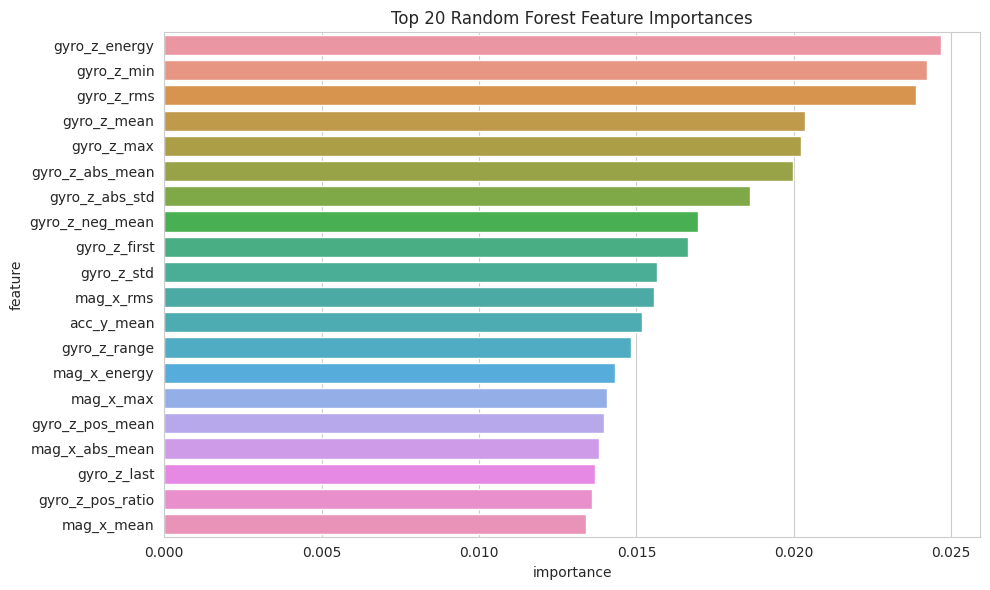

In [43]:
from harsh_event_model import build_window_dataset, train_event_model, save_model_bundle

# Train via reusable project module to keep runtime implementation aligned.
X_df, y_series = build_window_dataset(clean_df, window_size=WINDOW_SIZE, step_size=STEP_SIZE, min_event_ratio=0.20)
artifacts = train_event_model(X_df, y_series, test_size=0.20, random_state=SEED)

print('Random Forest classification report')
print(artifacts.class_report)

rf_bundle_path = ARTIFACT_DIR / 'harsh_event_rf.joblib'
save_model_bundle(
    output_path=rf_bundle_path,
    artifacts=artifacts,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=0.20,
)
print('Saved:', rf_bundle_path)

# Feature importance from RF stage inside the pipeline.
rf_model = artifacts.model.named_steps['rf']
fi = pd.DataFrame({'feature': artifacts.feature_columns, 'importance': rf_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature')
plt.title('Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 10. Model 2: Sequence Model (1D CNN + BiLSTM)

In [44]:
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class CNNBiLSTM(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=in_features, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: [B, T, F]
        x = x.transpose(1, 2)              # [B, F, T]
        x = self.conv(x)                   # [B, 64, T]
        x = x.transpose(1, 2)              # [B, T, 64]
        out, _ = self.lstm(x)              # [B, T, 128]
        pooled = out.mean(dim=1)           # [B, 128]
        return self.head(pooled)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

train_ds = SeqDataset(x_seq_train, y_train)
val_ds = SeqDataset(x_seq_val, y_val)
test_ds = SeqDataset(x_seq_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

seq_model = CNNBiLSTM(in_features=x_seq.shape[-1], n_classes=len(label_order)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor.to(device))
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

Using device: cpu


## 11. Training Loops, Hyperparameter Tuning, and Checkpointing

In [45]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1, np.array(all_labels), np.array(all_preds)

best_val_f1 = -1.0
best_state = None
history = []
PATIENCE = 6
patience_count = 0
EPOCHS = 25

for epoch in range(1, EPOCHS + 1):
    seq_model.train()
    train_loss_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = seq_model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += loss.item() * xb.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    val_loss, val_f1, _, _ = evaluate_model(seq_model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_macro_f1': val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in seq_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_f1:.4f}')
    if patience_count >= PATIENCE:
        print('Early stopping triggered.')
        break

if best_state is not None:
    seq_model.load_state_dict(best_state)

torch.save({
    'state_dict': seq_model.state_dict(),
    'label_order': label_order,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'feature_columns': feature_cols_stream,
}, ARTIFACT_DIR / 'harsh_event_cnn_bilstm.pt')

pd.DataFrame(history).to_csv(ARTIFACT_DIR / 'seq_training_history.csv', index=False)
print('Saved sequence checkpoint and training history.')

/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 01 | train_loss=1.8026 | val_loss=2.0977 | val_macro_f1=0.1122


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 02 | train_loss=1.2680 | val_loss=2.2528 | val_macro_f1=0.0617


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


...

Epoch 16 | train_loss=0.4842 | val_loss=2.1776 | val_macro_f1=0.2669


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 17 | train_loss=0.4609 | val_loss=3.4766 | val_macro_f1=0.1988


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 18 | train_loss=0.4843 | val_loss=2.7663 | val_macro_f1=0.2880
Early stopping triggered.
Saved sequence checkpoint and training history.


## 12. Evaluation: Per-Class Metrics, Confusion Matrix, PR Curves

Sequence model report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.0000    0.0000    0.0000        92
        harsh_left_turn     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.1344    0.2404    0.1724       104
       harsh_right_turn     0.0000    0.0000    0.0000         0
                   safe     0.7620    0.4330    0.5522       769
    sudden_acceleration     0.0116    0.0187    0.0143       107
         sudden_braking     0.0947    0.4286    0.1552        21

              micro avg     0.3376    0.3376    0.3376      1093
              macro avg     0.1433    0.1601    0.1277      1093
           weighted avg     0.5519    0.3376    0.4093      1093



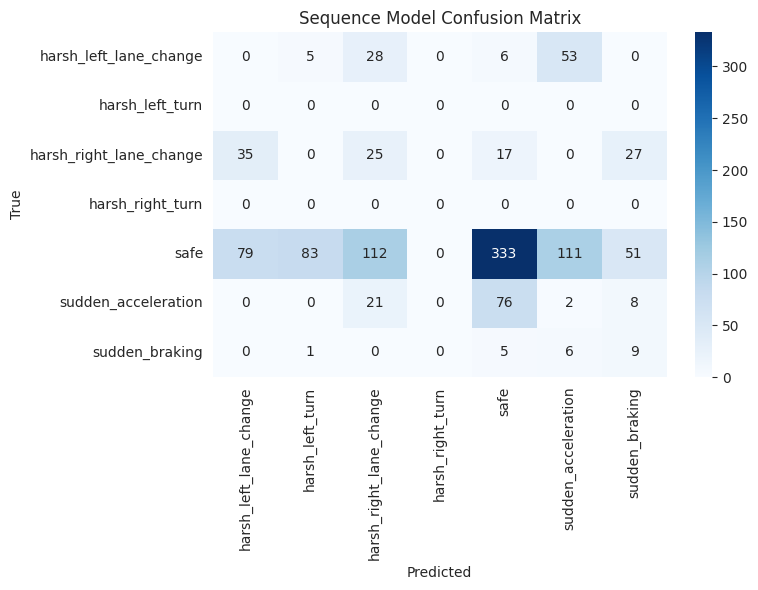

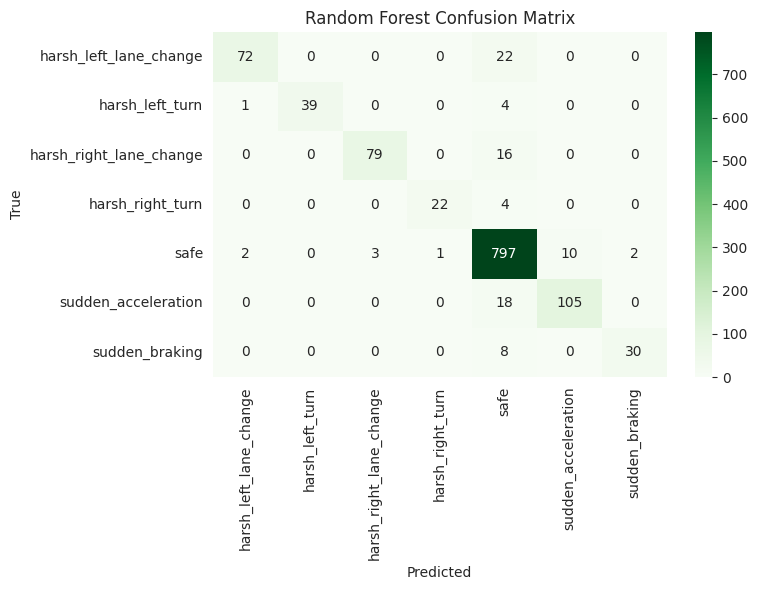

In [46]:
# Sequence model evaluation
_, _, y_true_seq, y_pred_seq = evaluate_model(seq_model, test_loader)

all_label_ids = list(range(len(label_order)))
print('Sequence model report:')
print(
    classification_report(
        y_true_seq,
        y_pred_seq,
        labels=all_label_ids,
        target_names=label_order,
        digits=4,
        zero_division=0,
    )
)

cm_seq = confusion_matrix(y_true_seq, y_pred_seq, labels=all_label_ids)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_seq,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.title('Sequence Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Baseline model confusion matrix on its own held-out split (inside train_event_model).
# We use artifacts.confusion_matrix directly from the reusable pipeline.
rf_labels = artifacts.label_encoder.inverse_transform(np.arange(artifacts.confusion_matrix.shape[0]))
plt.figure(figsize=(8, 6))
sns.heatmap(
    artifacts.confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf_labels,
    yticklabels=rf_labels,
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 13. Threshold Calibration and Temporal Smoothing

In [47]:
# Calibrate baseline probabilities using sigmoid (Platt scaling).
calibrated_rf = CalibratedClassifierCV(artifacts.model, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_df, artifacts.label_encoder.transform(y_series))
joblib.dump(calibrated_rf, ARTIFACT_DIR / 'harsh_event_rf_calibrated.joblib')

# Simple temporal debounce/hysteresis utility.
def debounce_predictions(labels, required_hits=2):
    out = []
    active = None
    hits = 0
    for lbl in labels:
        if lbl == 'safe':
            active = None
            hits = 0
            out.append('safe')
            continue
        if lbl == active:
            hits += 1
        else:
            active = lbl
            hits = 1
        out.append(lbl if hits >= required_hits else 'safe')
    return out

example_raw = ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
print('Raw      :', example_raw)
print('Debounced:', debounce_predictions(example_raw, required_hits=2))

Raw      : ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
Debounced: ['safe', 'safe', 'harsh_left_turn', 'safe', 'safe', 'sudden_braking']


## 14. Real-Time Inference Pipeline for CARLA Streaming IMU Data

In [48]:
from harsh_event_model import RealtimeHarshEventDetector

selected_csv = csv_files[6]
print(f'Streaming from deterministic file: {selected_csv.name}')

realtime_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)

# Mock stream simulator from one CSV. Replace this with CARLA live rows.
stream_df = pd.read_csv(selected_csv)
for c in imu_cols:
    stream_df[c] = pd.to_numeric(stream_df[c], errors='coerce')
stream_df = stream_df.dropna(subset=imu_cols).reset_index(drop=True)

emitted = []
for i, row in stream_df.iterrows():
    packet = {c: float(row[c]) for c in imu_cols}
    result = realtime_detector.update(packet)
    if isinstance(result, dict) and result.get('ready') and result.get('prediction') != 'safe':
        emitted.append({
            'idx': i,
            'timestamp': row.get('timestamp', i),
            'raw_prediction': result['raw_prediction'],
            'event': result['prediction'],
            'confidence': round(float(result['confidence']), 4),
        })

pd.DataFrame(emitted).head(20)

Streaming from deterministic file: paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv


,idx,timestamp,raw_prediction,event,confidence
0,84,20-2-2023_14:56:33:605515,sudden_acceleration,sudden_acceleration,0.8684
1,89,20-2-2023_14:56:33:861438,sudden_acceleration,sudden_acceleration,0.8192
2,94,20-2-2023_14:56:34:125401,sudden_acceleration,sudden_acceleration,0.8494
3,99,20-2-2023_14:56:34:380894,sudden_acceleration,sudden_acceleration,0.6432
4,104,20-2-2023_14:56:34:644901,sudden_acceleration,sudden_acceleration,0.5824
5,109,20-2-2023_14:56:34:904220,sudden_acceleration,sudden_acceleration,0.4540
6,129,20-2-2023_14:56:35:937099,sudden_braking,sudden_braking,0.5000
7,144,20-2-2023_14:56:36:717097,sudden_acceleration,sudden_acceleration,0.6391
8,149,20-2-2023_14:56:36:981058,sudden_acceleration,sudden_acceleration,0.7582
9,154,20-2-2023_14:56:37:237073,sudden_acceleration,sudden_acceleration,0.8643


Validated windows from paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv: 243
Detection accuracy on streamed windows: 0.4033
First mismatches:


,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
12,84,20-2-2023_14:56:33:605515,safe,sudden_acceleration,sudden_acceleration,0.8684,False
13,89,20-2-2023_14:56:33:861438,safe,sudden_acceleration,sudden_acceleration,0.8192,False
14,94,20-2-2023_14:56:34:125401,safe,sudden_acceleration,sudden_acceleration,0.8494,False
15,99,20-2-2023_14:56:34:380894,safe,sudden_acceleration,sudden_acceleration,0.6432,False
16,104,20-2-2023_14:56:34:644901,safe,sudden_acceleration,sudden_acceleration,0.5824,False
17,109,20-2-2023_14:56:34:904220,safe,sudden_acceleration,sudden_acceleration,0.4540,False
21,129,20-2-2023_14:56:35:937099,safe,sudden_braking,sudden_braking,0.5000,False
24,144,20-2-2023_14:56:36:717097,safe,sudden_acceleration,sudden_acceleration,0.6391,False
25,149,20-2-2023_14:56:36:981058,safe,sudden_acceleration,sudden_acceleration,0.7582,False
26,154,20-2-2023_14:56:37:237073,safe,sudden_acceleration,sudden_acceleration,0.8643,False


Realtime classification report:
                         precision    recall  f1-score   support

                   safe     0.5698    0.3311    0.4188       148
    sudden_acceleration     0.3356    0.5158    0.4066        95
         sudden_braking     0.0000    0.0000    0.0000         0
        harsh_left_turn     0.0000    0.0000    0.0000         0
       harsh_right_turn     0.0000    0.0000    0.0000         0
 harsh_left_lane_change     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.0000    0.0000    0.0000         0

              micro avg     0.4033    0.4033    0.4033       243
              macro avg     0.1293    0.1210    0.1179       243
           weighted avg     0.4782    0.4033    0.4140       243



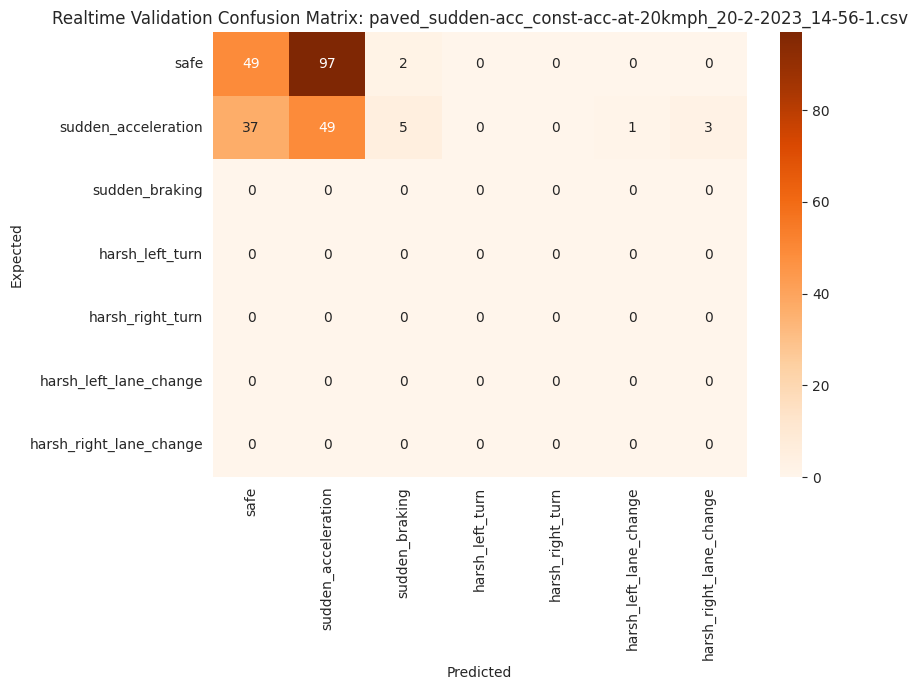

,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
0,24,20-2-2023_14:56:30:493871,safe,safe,safe,0.9114,True
1,29,20-2-2023_14:56:30:749889,safe,safe,safe,0.9493,True
2,34,20-2-2023_14:56:31:5800,safe,safe,safe,0.9465,True
3,39,20-2-2023_14:56:31:269812,safe,safe,safe,0.9470,True
4,44,20-2-2023_14:56:31:525780,safe,safe,safe,0.9647,True
5,49,20-2-2023_14:56:31:781698,safe,safe,safe,0.9399,True
6,54,20-2-2023_14:56:32:45718,safe,harsh_right_lane_change,safe,0.9390,True
7,59,20-2-2023_14:56:32:301646,safe,safe,safe,0.9303,True
8,64,20-2-2023_14:56:32:565599,safe,safe,safe,0.9171,True
9,69,20-2-2023_14:56:32:821569,safe,safe,safe,0.8122,True


In [49]:
from harsh_event_model import EVENT_CLASSES, infer_event_from_filename, normalize_event_name

file_event = infer_event_from_filename(selected_csv.name)
if file_event == 'safe':
    active_event = normalize_event_name(stream_df['harsh_event'].mode(dropna=True).iloc[0])
else:
    active_event = file_event

validation_df = stream_df.copy()
validation_df['expected_row_label'] = np.where(
    pd.to_numeric(validation_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
    active_event,
    'safe',
)

validation_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)
validation_detector.model.named_steps['rf'].set_params(n_jobs=1)

realtime_records = []
for i, row in enumerate(validation_df.itertuples(index=False), start=0):
    packet = {c: float(getattr(row, c)) for c in imu_cols}
    result = validation_detector.update(packet)
    if not (isinstance(result, dict) and result.get('ready')):
        continue

    window_start = i - validation_detector.window_size + 1
    expected_window = validation_df.iloc[window_start : i + 1]['expected_row_label']
    non_safe = expected_window[expected_window != 'safe']
    if len(non_safe) == 0 or (len(non_safe) / validation_detector.window_size) < validation_detector.bundle['min_event_ratio']:
        expected_label = 'safe'
    else:
        expected_label = non_safe.value_counts().idxmax()

    realtime_records.append({
        'idx': i,
        'timestamp': getattr(row, 'timestamp', i),
        'expected_event': expected_label,
        'raw_prediction': result['raw_prediction'],
        'prediction': result['prediction'],
        'confidence': round(float(result['confidence']), 4),
        'correct': result['prediction'] == expected_label,
    })

realtime_eval_df = pd.DataFrame(realtime_records)
print(f'Validated windows from {selected_csv.name}: {len(realtime_eval_df)}')
print('Detection accuracy on streamed windows:', round(realtime_eval_df['correct'].mean(), 4))

print('First mismatches:')
display(realtime_eval_df.loc[~realtime_eval_df['correct']].head(10))

print('Realtime classification report:')
print(
    classification_report(
        realtime_eval_df['expected_event'],
        realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

cm_realtime = confusion_matrix(
    realtime_eval_df['expected_event'],
    realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_realtime,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title(f'Realtime Validation Confusion Matrix: {selected_csv.name}')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

display(realtime_eval_df.head(20))

,file_name,windows_evaluated,accuracy,expected_non_safe_windows,predicted_non_safe_windows,false_positive_windows,false_negative_windows
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,243,0.4033,95,157,99,37
12,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,57,0.4035,30,24,11,17
14,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,62,0.5484,39,16,2,25
11,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,81,0.5556,48,53,20,15
17,paved_sudden-acc_const-acc-at-60kmph_22-3-2023...,95,0.5579,39,32,17,24
13,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,72,0.5833,37,19,5,23
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,96,0.6562,48,81,33,0
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,184,0.6739,0,60,60,0
24,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,56,0.6786,20,21,8,7
19,paved_sudden-brake_const-acc-at-20kmph_20-2-20...,202,0.6881,45,32,22,35


Overall realtime classification report across all files:
                         precision    recall  f1-score   support

                   safe     0.8561    0.8344    0.8451      4257
    sudden_acceleration     0.5791    0.6488    0.6120       615
         sudden_braking     0.3153    0.3646    0.3382       192
        harsh_left_turn     0.9351    0.7793    0.8501       222
       harsh_right_turn     0.8667    0.6000    0.7091       130
 harsh_left_lane_change     0.5813    0.7580    0.6580       467
harsh_right_lane_change     0.8814    0.7679    0.8207       474

               accuracy                         0.7850      6357
              macro avg     0.7164    0.6790    0.6905      6357
           weighted avg     0.7976    0.7850    0.7891      6357



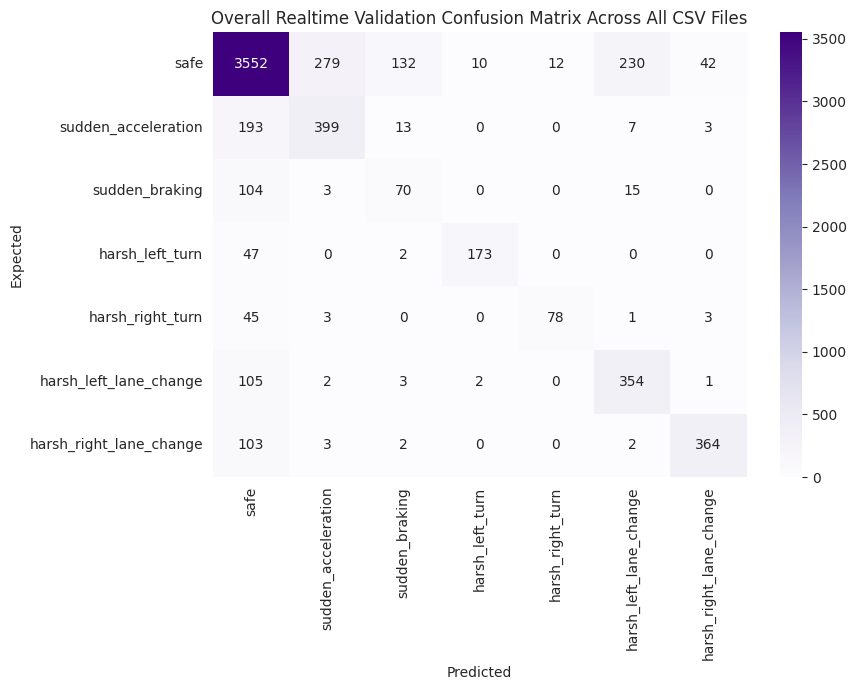

In [50]:
all_realtime_records = []
per_file_metrics = []

for candidate_csv in csv_files:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )

    detector = RealtimeHarshEventDetector(
        model_bundle_path=rf_bundle_path,
        min_confidence=0.45,
        consecutive_hits=2,
    )
    detector.model.named_steps['rf'].set_params(n_jobs=1)

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_realtime_records.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_file_metrics.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_realtime_eval_df = pd.DataFrame(all_realtime_records)
per_file_metrics_df = pd.DataFrame(per_file_metrics).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

display(per_file_metrics_df.head(20))

print('Overall realtime classification report across all files:')
print(
    classification_report(
        all_realtime_eval_df['expected_event'],
        all_realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

overall_cm = confusion_matrix(
    all_realtime_eval_df['expected_event'],
    all_realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    overall_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title('Overall Realtime Validation Confusion Matrix Across All CSV Files')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

## 15. Model Export and Runtime Integration Hooks

In [51]:
# Runtime integration API stub for CARLA client usage.
def predict_event_from_packet(detector, packet):
    """
    packet schema expected:
    {
      'acc_x': float, 'acc_y': float, 'acc_z': float,
      'gyro_x': float, 'gyro_y': float, 'gyro_z': float,
      'mag_x': float, 'mag_y': float, 'mag_z': float
    }
    """
    return detector.update(packet)

print('Exported artifacts:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

print('\nSafety score integration hook:')
print('Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.')

Exported artifacts:
- harsh_event_cnn_bilstm.pt
- harsh_event_rf.joblib
- harsh_event_rf_calibrated.joblib
- seq_training_history.csv
- split_manifest.csv

Safety score integration hook:
Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.
